In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import networkx as nx
import torch

import sys
sys.path.append('../')
from proof_of_concept.models.staged import STAGED
from proof_of_concept.utils.graph_constructor import GraphConstructor
from proof_of_concept.utils.simulated_data_processing import retrieve_simulated_data,retrieve_real_data

from proof_of_concept.tests.test_graph_constructor import create_square_grid_data as create_test_data
from proof_of_concept.utils.visualization import visualize_attention_graph, visualize_graph

In [2]:
data = retrieve_real_data(data_dir='../data/real')

In [3]:
for key, value in data.items():
    if isinstance(value, (torch.Tensor, np.ndarray)):
        print(f"{key}: {value.shape}")
    elif isinstance(value, (list, dict)):
        print(f"{key}: length {len(value)}")
    else:
        print(f"{key}: {value}")

gene_expression: torch.Size([10, 100, 428])
cell_positions: torch.Size([10, 100, 2])
genes: length 428
cell_type_assignments: torch.Size([100])
prior_grns: length 8
receptor_gene_pairs: length 3
ligand_receptor_pairs: length 3
n_time_points: 10
n_cells: 100
n_genes: 428


In [4]:
import os
import pickle

# Load config for future model use
config_path = os.path.join('../results', "config.pkl")
with open(config_path, "rb") as handle:
    config = pickle.load(handle)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = STAGED(
    num_genes=len(data['genes']),
    hidden_dim=config['model_config'].hidden_dim,
    num_gat_layers=config['model_config'].num_gat_layers,
    num_mlp_layers=config['model_config'].num_mlp_layers,
    dropout=config['model_config'].dropout,
    delta_gl=config['model_config'].delta_gl,
    delta_lr=config['model_config'].delta_lr,
    delta_rg=config['model_config'].delta_rg,
    delta_gg=config['model_config'].delta_gg,
    add_self_loops=config['model_config'].add_self_loops,
).to(device)
import os
import pickle

# Load results object from output directory
model_path = os.path.join('../results/real/ode/euler', "model.pt")
model.load_state_dict(torch.load(model_path))
model

/var/folders/1r/l8_zwkvx7_g7b632hf_1517c0000gn/T/ipykernel_47111/370593563.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))

STAGED(
  (gat_layers): ModuleList(
    (0): GATConv(1, 64, heads=1)
  )
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [5]:
graph_constructor = GraphConstructor(
    genes=data['genes'],
    ligand_receptor_pairs=data['ligand_receptor_pairs'],
    receptor_gene_pairs=data['receptor_gene_pairs'],
    cell_type_assignments=data['cell_type_assignments'],
    prior_grns=data['prior_grns']
)

# Define time lags as specified by the user
delta_gl = 1  # Time lag for gene -> ligand
delta_lr = 2  # Time lag for ligand -> receptor
delta_rg = 1  # Time lag for receptor -> gene
delta_gg = 0  # Time lag for gene -> gene

time_point = 8


# Ensure time_point is large enough to handle the lags
max_lag = max(delta_gl, delta_lr, delta_rg, delta_gg)
if time_point < max_lag:
    time_point = max_lag
    print(f"Adjusted time_point to {time_point} to handle time lags")


In [6]:
cell_indices = list(range(data['cell_type_assignments'].shape[0]))
cell_types = data['cell_type_assignments'].tolist()
cell_idx_type_list = list(zip(cell_indices, cell_types))
cell_idx_type_list[:20]  # Show the first 10 as an example


[(0, 0),
 (1, 7),
 (2, 1),
 (3, 2),
 (4, 5),
 (5, 5),
 (6, 1),
 (7, 5),
 (8, 5),
 (9, 5),
 (10, 7),
 (11, 5),
 (12, 0),
 (13, 0),
 (14, 0),
 (15, 2),
 (16, 7),
 (17, 1),
 (18, 1),
 (19, 6)]

In [7]:
cell_idx = 0
target_gene = 'TMEM163'
base_graph = graph_constructor.construct_base_graph(cell_idx)

In [8]:
distance_threshold = 1
updated_graph = graph_constructor.update_graph_with_neighbors(
    base_graph, cell_idx, data['cell_positions'], time_point,
    distance_threshold=distance_threshold
)

In [9]:
# pos = visualize_graph(updated_graph, f"updated GRN for cell {cell_idx}", save_plot=False, show_plot=True, figsize=(7, 5), return_pos=True)

In [10]:
pyg_graph = graph_constructor.assign_node_features(
    updated_graph, cell_idx, time_point, data['gene_expression'],
    delta_gl, delta_lr, delta_rg, delta_gg
)

In [11]:
node_embeddings, (edge_index, attention_weights) = model(pyg_graph)

In [12]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def visualize_single_gene_attention(pyg_graph, edge_index, attention_weights, target_gene, 
                           figsize=(12, 10), show_labels=True, highlight_mode='both', top_k=10,
                           layout='spring', layout_kwargs=None):
    """
    Visualize a graph with attention weights focused on a specific gene and its most attended connections.
    
    Args:
        pyg_graph: PyTorch Geometric graph object containing node names and types
        edge_index: Tensor containing edge indices
        attention_weights: Tensor containing attention weights
            from `node_embeddings, (edge_index, attention_weights) = model(pyg_graph)`
        target_gene: Name of the gene to focus on
        figsize: Tuple specifying figure size
        show_labels: Whether to show node labels (default: True)
        highlight_mode: 'incoming', 'outgoing', or 'both' (default: 'both')
        top_k: Number of top attention connections to display (default: 10)
        layout: Layout algorithm to use ('spring', 'circular', 'kamada_kawai', 'random') (default: 'spring')
        layout_kwargs: Additional keyword arguments for the layout function (default: None)
        
    Returns:
        None. Displays the graph visualization.
    """
    # Create node names mapping
    node_names = pyg_graph.node_names

    # Check if target gene exists
    if target_gene not in node_names:
        print(f"Warning: Gene '{target_gene}' not found in the graph.")
        print(f"Available genes: {[name for name, type_ in zip(node_names, pyg_graph.node_types) if type_ == 'gene']}")
        return

    # Create mapping from node names to their types
    node_name_to_type = {name: type_ for name, type_ in zip(pyg_graph.node_names, pyg_graph.node_types)}

    # Compute average attention weights across heads for visualization
    avg_attention = attention_weights.mean(dim=1).detach().numpy()

    # Find edges related to target gene and their attention weights
    target_connections = []
    
    for i, (src, dst) in enumerate(edge_index.t().tolist()):
        src_name = node_names[src]
        dst_name = node_names[dst]
        
        is_target_edge = False
        if highlight_mode == 'incoming' and dst_name == target_gene:
            is_target_edge = True
        elif highlight_mode == 'outgoing' and src_name == target_gene:
            is_target_edge = True
        elif highlight_mode == 'both' and (src_name == target_gene or dst_name == target_gene):
            is_target_edge = True
            
        if is_target_edge:
            target_connections.append((src_name, dst_name, avg_attention[i]))

    if not target_connections:
        print(f"No connections found for {target_gene} in {highlight_mode} mode.")
        return

    # Sort by attention weight and take top_k connections
    target_connections.sort(key=lambda x: x[2], reverse=True)
    top_connections = target_connections[:top_k]

    # Extract nodes involved in top connections
    nodes_to_plot = {target_gene}
    edges_to_plot = []
    attention_values = []
    
    for src, dst, att in top_connections:
        nodes_to_plot.add(src)
        nodes_to_plot.add(dst)
        edges_to_plot.append((src, dst))
        attention_values.append(att)

    # Create a focused NetworkX graph with only relevant nodes and edges
    G = nx.DiGraph()
    G.add_nodes_from(nodes_to_plot)
    G.add_edges_from(edges_to_plot)

    # Compute layout positions for the subgraph
    if layout_kwargs is None:
        layout_kwargs = {}
    
    # Available layout algorithms
    layout_functions = {
        'spring': nx.spring_layout,
        'circular': nx.circular_layout,
        'kamada_kawai': nx.kamada_kawai_layout,
        'random': nx.random_layout,
        'shell': nx.shell_layout,
        'planar': nx.planar_layout if nx.is_planar(G) else nx.spring_layout
    }
    
    # Use spring layout as fallback if requested layout is not available
    if layout not in layout_functions:
        print(f"Warning: Layout '{layout}' not recognized. Using 'spring' layout instead.")
        layout = 'spring'
    
    # Special handling for spring layout to make target gene more central
    if layout == 'spring':
        # Set default parameters for spring layout to create better visualization
        spring_kwargs = {
            'k': 2.0,  # Optimal distance between nodes
            'iterations': 100,  # Number of iterations
            'seed': 42  # For reproducible layouts
        }
        spring_kwargs.update(layout_kwargs)
        
        # Try to position target gene more centrally
        fixed_positions = {target_gene: (0, 0)} if len(nodes_to_plot) > 1 else {}
        if fixed_positions:
            spring_kwargs['pos'] = fixed_positions
            spring_kwargs['fixed'] = [target_gene]
        
        pos = layout_functions[layout](G, **spring_kwargs)
    else:
        pos = layout_functions[layout](G, **layout_kwargs)

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Create color map for node types
    node_type_colors = {
        'gene': 'lightblue',
        'receptor': 'lightgreen', 
        'ligand': 'orange',
        'input_ligand': 'salmon'
    }

    # Get node colors, highlighting target gene
    node_colors = []
    node_sizes = []
    for node in G.nodes():
        if node == target_gene:
            node_colors.append('red')  # Highlight target gene in red
            node_sizes.append(500)  # Make target gene larger
        else:
            node_colors.append(node_type_colors.get(node_name_to_type[node], 'gray'))
            node_sizes.append(300)

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes)
    
    # Draw edges with attention-based coloring and width
    if edges_to_plot:
        # Create a mapping from edges to their attention values
        edge_to_attention = {(src, dst): att for (src, dst), att in zip(edges_to_plot, attention_values)}
        
        # Get attention values in the same order as G.edges()
        ordered_attention_values = []
        ordered_edge_widths = []
        
        for edge in G.edges():
            att_value = edge_to_attention[edge]
            ordered_attention_values.append(att_value)
        
        attention_array = np.array(ordered_attention_values)
        
        # Scale edge widths based on attention (1-5 range)
        if len(attention_array) > 1:
            min_att, max_att = attention_array.min(), attention_array.max()
            if max_att > min_att:
                # Normalize for width scaling (0-1 range)
                norm_weights_for_width = (attention_array - min_att) / (max_att - min_att)
            else:
                norm_weights_for_width = np.ones_like(attention_array)
        else:
            norm_weights_for_width = np.array([1.0])
            
        edge_widths = 1 + 4 * norm_weights_for_width
        
        # Create explicit color normalization to ensure consistency
        vmin, vmax = attention_array.min(), attention_array.max()
        norm = plt.Normalize(vmin=vmin, vmax=vmax)
        
        # Use the same attention values and normalization for both edges and colorbar
        nx.draw_networkx_edges(G, pos, ax=ax, edge_color=attention_array,
                              edge_cmap=plt.cm.Reds, width=edge_widths, arrows=True, 
                              arrowsize=20, connectionstyle="arc3,rad=0.1",
                              edge_vmin=vmin, edge_vmax=vmax)

    # Add node labels if requested
    if show_labels:
        # Make target gene label bold - INCREASED FONT SIZE
        label_dict = {}
        for node in G.nodes():
            if node == target_gene:
                label_dict[node] = f"**{node}**"
            else:
                label_dict[node] = node
        nx.draw_networkx_labels(G, pos, labels=label_dict, ax=ax, font_size=16, font_weight='bold')

    # Add edge labels for attention weights - INCREASED FONT SIZE
    edge_labels = {}
    for (src, dst), att in zip(edges_to_plot, attention_values):
        edge_labels[(src, dst)] = f'{att:.3f}'
    
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, 
                                ax=ax, font_size=14, bbox=dict(boxstyle='round,pad=0.2', 
                                facecolor='white', alpha=0.8))

    # Add colorbar for attention weights - REMOVED TICKS
    if attention_values:
        sm = plt.cm.ScalarMappable(cmap=plt.cm.Reds, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, label=f'Attention Weight')
        cbar.set_ticks([])  # Remove colorbar ticks

    # Add legend for node types (including highlighted target) - INCREASED FONT SIZE
    legend_elements = []
    present_types = set(node_name_to_type[node] for node in nodes_to_plot if node != target_gene)
    
    for node_type in present_types:
        if node_type in node_type_colors:
            legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                            markerfacecolor=node_type_colors[node_type], 
                                            label=node_type, markersize=10))
    
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                    markerfacecolor='red', label=f'Target: {target_gene}', markersize=12))
    
    ax.legend(handles=legend_elements, loc='upper right', title='Node Types', fontsize=14, title_fontsize=16)

    # TITLE REMOVED - No ax.set_title() call
    
    # Remove axis for cleaner look
    ax.set_axis_off()
    
    # Print summary statistics
    print(f"\nFocused Attention Analysis for {target_gene}:")
    print(f"Showing top {len(edges_to_plot)} of {len(target_connections)} total connections")
    print(f"Nodes in visualization: {len(nodes_to_plot)}")
    print(f"Layout algorithm used: {layout}")
    print(f"Average attention weight (shown): {np.mean(attention_values):.4f}")
    print(f"Max attention weight (shown): {np.max(attention_values):.4f}")
    print(f"Min attention weight (shown): {np.min(attention_values):.4f}")
    
    # Show the connections with their weights
    print(f"\nTop {len(edges_to_plot)} connections (by attention weight):")
    for i, (src, dst, weight) in enumerate(top_connections):
        if src == target_gene:
            direction = f"{target_gene} → {dst}"
        else:
            direction = f"{src} → {target_gene}"
        print(f"  {i+1}. {direction}: {weight:.4f}")

    plt.tight_layout()
    
    return G, pos, attention_values

In [13]:
print(cell_idx_type_list[cell_idx][1])

0



Focused Attention Analysis for TMEM163:
Showing top 10 of 50 total connections
Nodes in visualization: 10
Layout algorithm used: spring
Average attention weight (shown): 0.0995
Max attention weight (shown): 0.1120
Min attention weight (shown): 0.0336

Top 10 connections (by attention weight):
  1. SREBF2-AS1 → TMEM163: 0.1120
  2. ADAMTS4 → TMEM163: 0.1120
  3. DPP4 → TMEM163: 0.1120
  4. CYCS → TMEM163: 0.1119
  5. ZDHHC19 → TMEM163: 0.1119
  6. LINC00467 → TMEM163: 0.1118
  7. SEC24B-AS1 → TMEM163: 0.1115
  8. TMEM163 → TMEM163: 0.1065
  9. TMEM163 → LIPC: 0.0715
  10. TMEM163 → MGMT: 0.0336


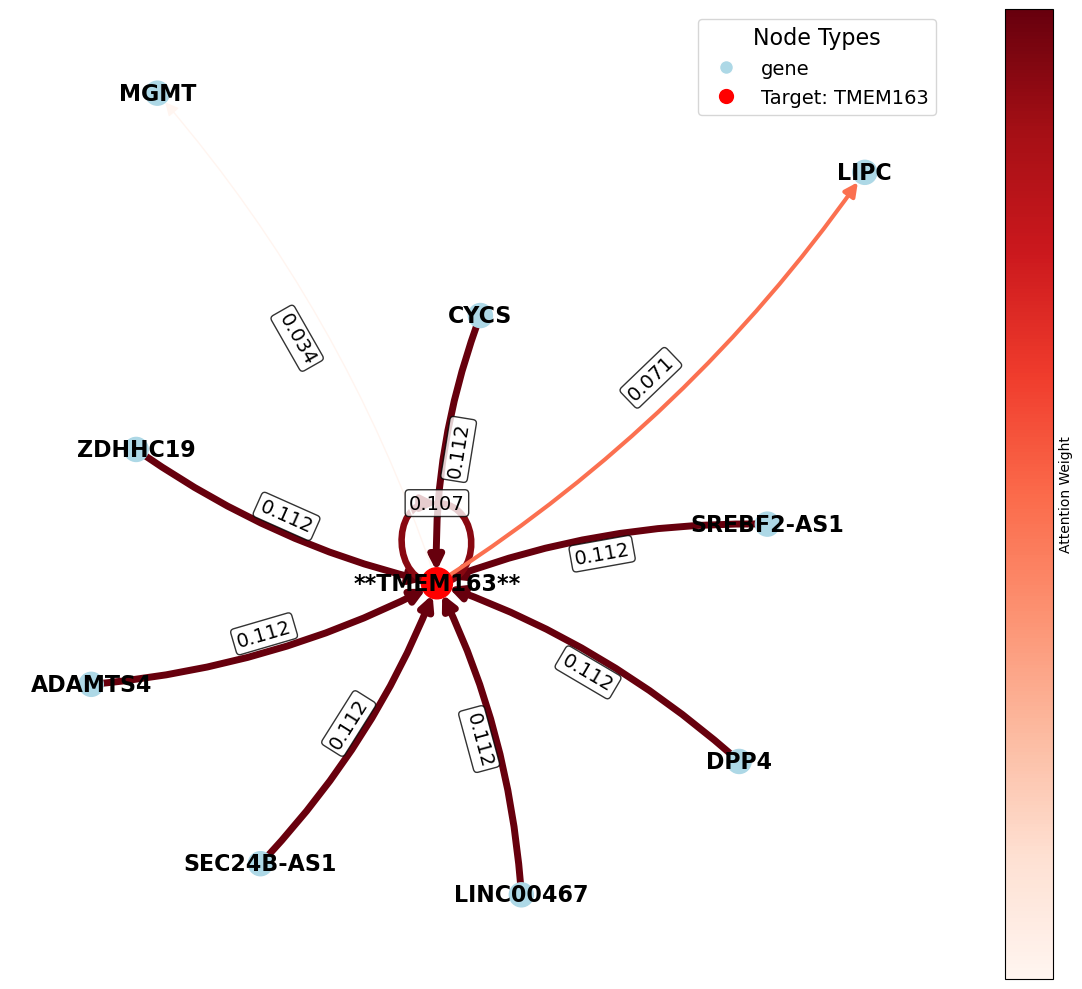

In [14]:
visualize_single_gene_attention(pyg_graph, edge_index, attention_weights, target_gene=target_gene, 
                           figsize=(12, 10), show_labels=True, highlight_mode='both', top_k=10,
                           layout='spring', layout_kwargs=None)

plt.savefig(f'../inference_results/plots/cell_type_{cell_idx_type_list[cell_idx][1]}/attention_{target_gene}.png', bbox_inches='tight')